Dataset Shape: (50000, 21)
Sample Size: 5000


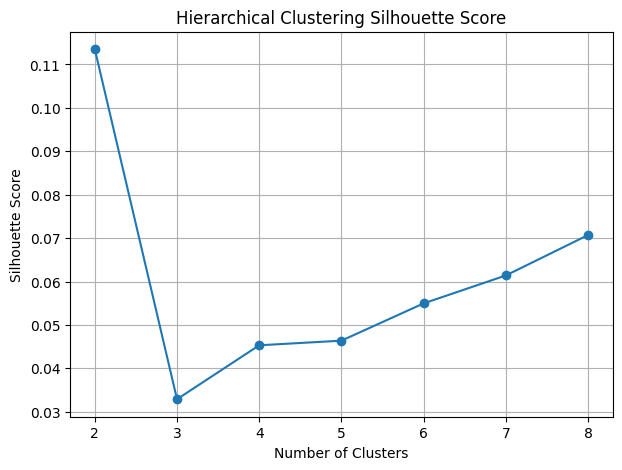

Best Number of Clusters: 2
Best Silhouette Score: 0.11351824781889372

Cluster Counts:
0    4384
1     616
Name: count, dtype: int64


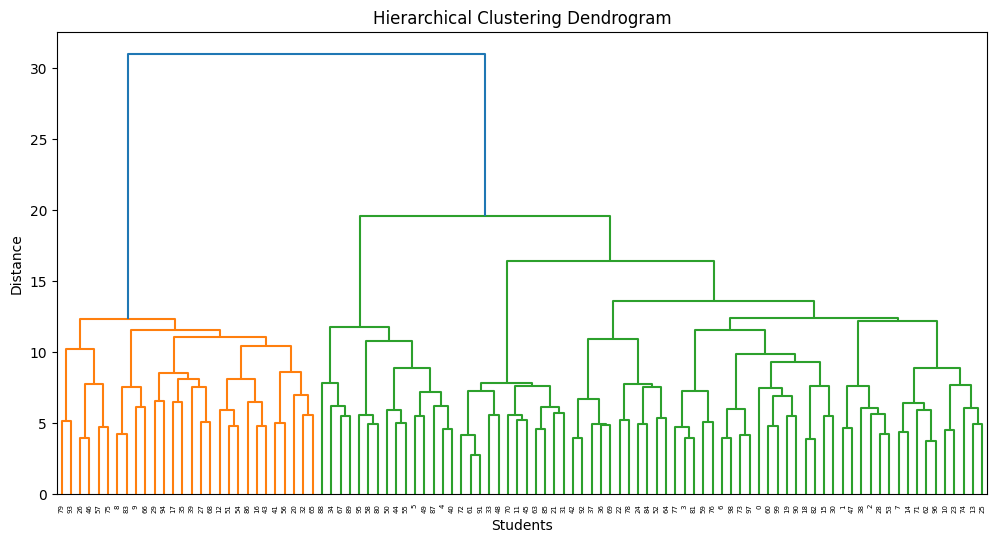

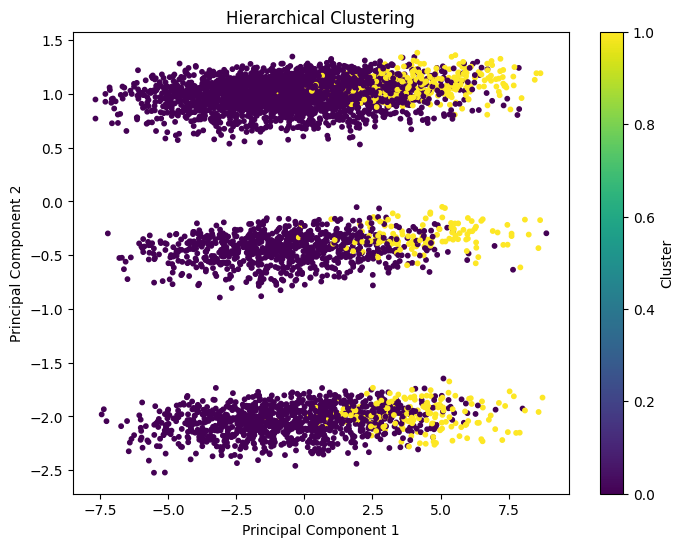

In [1]:
# ============================================================
# HIERARCHICAL CLUSTERING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("/content/placement_predict_50k_adjusted (1).csv")

print("Dataset Shape:", df.shape)

# ------------------------------------------------------------
# 2. Select Features
# ------------------------------------------------------------

numeric_cols = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]

categorical_cols = [
    "Gender",
    "City",
    "CollegeTier",
    "Stream",
    "Specialisation",
    "Hostel",
    "HistoryOfBacklogs",
    "ExtraCurricular"
]

# ------------------------------------------------------------
# 3. Preprocessing
# ------------------------------------------------------------

imputer = SimpleImputer(strategy="median")

num_data = pd.DataFrame(
    imputer.fit_transform(df[numeric_cols]),
    columns=numeric_cols
)

cat_data = pd.get_dummies(
    df[categorical_cols],
    drop_first=True
)

features = pd.concat(
    [num_data, cat_data],
    axis=1
)

scaler = StandardScaler()

X = scaler.fit_transform(features)

# ------------------------------------------------------------
# 4. Take Sample for Hierarchical Clustering
# ------------------------------------------------------------

sample_size = min(5000, len(X))

np.random.seed(42)

sample_indices = np.random.choice(
    len(X),
    sample_size,
    replace=False
)

X_sample = X[sample_indices]

print("Sample Size:", len(X_sample))

# ------------------------------------------------------------
# 5. Test Different Number of Clusters
# ------------------------------------------------------------

K = range(2, 9)

scores = []

for k in K:

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X_sample)

    score = silhouette_score(
        X_sample,
        labels
    )

    scores.append(score)

# ------------------------------------------------------------
# 6. Silhouette Score Graph
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

plt.plot(
    K,
    scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering Silhouette Score")
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 7. Best K
# ------------------------------------------------------------

best_k = list(K)[np.argmax(scores)]

print("Best Number of Clusters:", best_k)
print("Best Silhouette Score:", max(scores))

# ------------------------------------------------------------
# 8. Final Hierarchical Model
# ------------------------------------------------------------

hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

labels = hierarchical.fit_predict(X_sample)

print("\nCluster Counts:")
print(pd.Series(labels).value_counts().sort_index())

# ------------------------------------------------------------
# 9. Dendrogram
# ------------------------------------------------------------

dendrogram_size = min(100, len(X_sample))

Z = linkage(
    X_sample[:dendrogram_size],
    method="ward"
)

plt.figure(figsize=(12,6))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Students")
plt.ylabel("Distance")

plt.show()

# ------------------------------------------------------------
# 10. PCA Visualization
# ------------------------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap="viridis",
    s=10
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clustering")
plt.colorbar(label="Cluster")

plt.show()